# 11 — Il crollo crypto attuale e il ciclo dell'halving: a quale momento storico assomiglia?

**Domanda dell'utente**: "le mie crypto stanno colando a picco — è successo qualcosa di
strano, a quale evento/momento storico è associato?"

**Principio guida (giusto)**: *la storia ci insegna che conoscere il passato aiuta a
identificare pattern e cicli che si ripetono.* Il ciclo dell'halving di Bitcoin (~4 anni) è
il pattern ricorrente più citato del crypto. Questo notebook lo prende **sul serio** e lo
rende **misurabile e riproducibile** — allineando ogni ciclo passato allo stesso "orologio"
(giorni dall'halving) per confrontare dove eravamo *alla stessa fase*.

**Onestà metodologica (CLAUDE.md, VISION #1)**: ci sono solo **3-4 cicli completi**. È
*descrizione di pattern*, non una legge statistica: 3 punti non fanno una legge. Dice
**dove siamo** in una struttura ricorrente — non cosa farà il prezzo domani.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.assets.asset import TIER1_ASSETS, get_asset_by_symbol
from src.ingestion.tier1.yahoo_finance import YahooFinanceSource
from src.features.cycle_analysis import compare_cycles, days_since_last_halving, HALVING_DATES

plt.rcParams['figure.figsize'] = (12, 5)
src = YahooFinanceSource()
TODAY = pd.Timestamp.now(tz='UTC').normalize()


## 1. Lo stato attuale dei Tier 1 (quanto è grave il crollo?)
Drawdown dal massimo dell'ultimo anno per ogni asset del portafoglio.

In [2]:
rows = []
panel = {}
for a in TIER1_ASSETS:
    df = src.fetch_ohlcv(a, start='2024-01-01', interval='1d').sort_index()
    panel[a.symbol] = df['close']
    c = df['close']
    last = float(c.iloc[-1])
    d7 = (last/float(c.iloc[-8])-1)*100
    d30 = (last/float(c.iloc[-31])-1)*100
    max1y = float(c.iloc[-365:].max())
    rows.append({'asset': a.symbol, 'prezzo': round(last,2),
                 '7g%': round(d7,1), '30g%': round(d30,1),
                 'dal_max_1y%': round((last/max1y-1)*100,1)})
status = pd.DataFrame(rows).set_index('asset')
print(status.to_string())
print(f"\nLe altcoin scendono molto più di BTC: è il pattern CLASSICO dei bear crypto")
print(f"(le altcoin amplificano sia i rialzi che i ribassi di Bitcoin).")


         prezzo   7g%  30g%  dal_max_1y%
asset                                   
BTC    63591.35 -13.5 -21.4        -49.0
ETH     1773.16 -11.7 -24.9        -63.3
SOL       68.63 -16.3 -20.5        -72.3
LINK       8.01 -10.9 -18.0        -70.1
POL        0.22   0.8 -27.5        -79.3

Le altcoin scendono molto più di BTC: è il pattern CLASSICO dei bear crypto
(le altcoin amplificano sia i rialzi che i ribassi di Bitcoin).


## 2. BTC: regime e posizione nel ciclo
Bitcoin è il metronomo: il ciclo dell'halving si misura su di lui.

In [3]:
btc = src.fetch_ohlcv(get_asset_by_symbol('BTC'), start='2014-01-01', interval='1d').sort_index()['close']
last = float(btc.iloc[-1])
sma200 = float(btc.rolling(200).mean().iloc[-1])
ath = float(btc.cummax().iloc[-1])
phase = days_since_last_halving(TODAY)
print(f"BTC oggi: {last:,.0f}  ({btc.index[-1].date()})")
print(f"Massimo del ciclo: {ath:,.0f}  ->  drawdown {(last/ath-1)*100:+.0f}%")
print(f"SMA200: {sma200:,.0f}  ->  REGIME: {'BULL (sopra)' if last>=sma200 else 'BEAR (sotto)'}")
print(f"\nUltimo halving: {max(h for h in HALVING_DATES if h<=TODAY).date()}")
print(f"Siamo a {phase} giorni dall'halving (~{phase/30:.1f} mesi nel ciclo).")


BTC oggi: 63,591  (2026-06-04)
Massimo del ciclo: 124,753  ->  drawdown -49%
SMA200: 78,932  ->  REGIME: BEAR (sotto)

Ultimo halving: 2024-04-20
Siamo a 775 giorni dall'halving (~25.8 mesi nel ciclo).


## 3. Il confronto storico — il cuore dell'analisi
Per ogni ciclo passato, guardiamo dove eravamo **alla stessa identica fase** (stessi giorni
dall'halving di oggi). Se i cicli si ripetono, dovremmo vedere uno schema coerente.

In [4]:
stats = compare_cycles(btc, TODAY)
table = []
for s in stats:
    table.append({
        'halving': str(s.halving_date.date()),
        'picco_$': f'{s.peak_price:,.0f}',
        'picco_giorni_dopo': s.peak_days_after,
        f'a_{s.phase_days}g_$': f'{s.price_at_phase:,.0f}' if s.price_at_phase else 'n/d',
        'drawdown_dal_picco%': round(s.drawdown_from_peak_pct,0) if s.drawdown_from_peak_pct is not None else None,
        'bottom_$': f'{s.bottom_price:,.0f}',
        'bottom_giorni_dopo': s.bottom_days_after,
    })
comp = pd.DataFrame(table)
print(comp.to_string(index=False))


   halving picco_$  picco_giorni_dopo a_775g_$  drawdown_dal_picco% bottom_$  bottom_giorni_dopo
2016-07-09  19,497                525    6,535                -66.0    3,237                 889
2020-05-11  67,567                546   21,502                -68.0   15,787                 924
2024-04-20 124,753                534   63,591                -49.0   62,702                 656


## 4. Visualizzazione: tutti i cicli sullo stesso orologio
Ogni ciclo normalizzato a 100 al momento dell'halving, asse x = giorni dall'halving. La
linea verticale rossa è **dove siamo ora**.

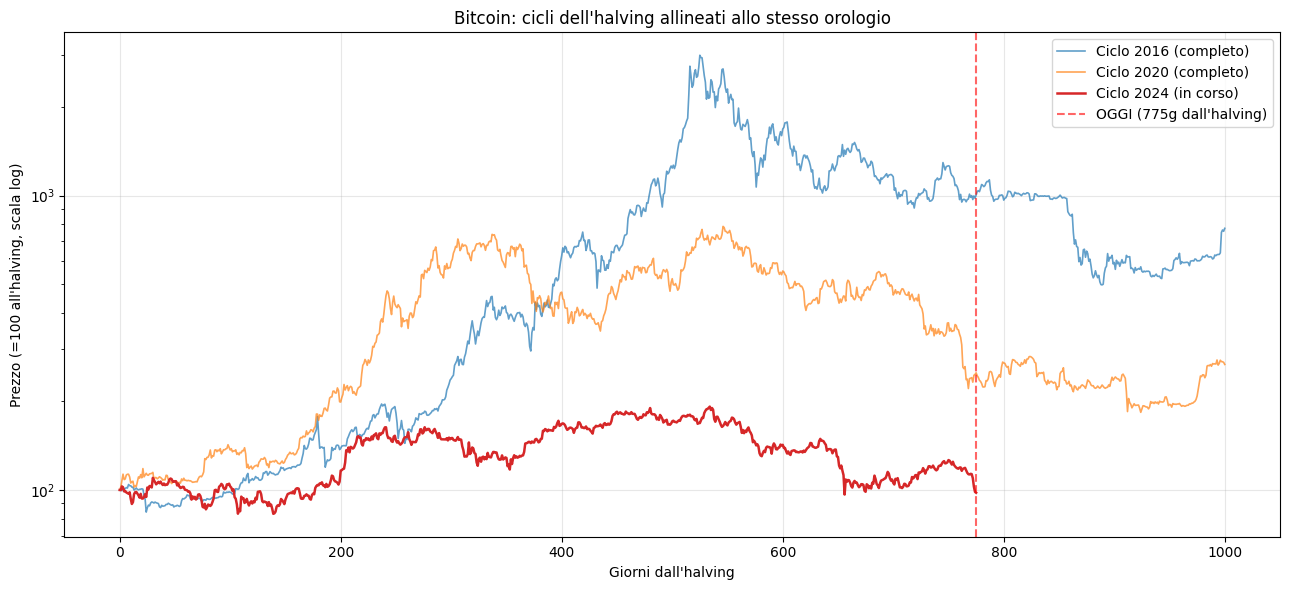

In [5]:
fig, ax = plt.subplots(figsize=(13,6))
phase = days_since_last_halving(TODAY)
colors = {'2016-07-09':'tab:blue','2020-05-11':'tab:orange','2024-04-20':'tab:red'}
for h in HALVING_DATES:
    key = str(h.date())
    if key not in colors: continue
    seg = btc[(btc.index>=h) & (btc.index<=h+pd.Timedelta(days=1000))]
    if seg.empty: continue
    x = [(d-h).days for d in seg.index]
    y = seg.values / float(seg.iloc[0]) * 100
    label = f'Ciclo {h.year} ({"in corso" if key=="2024-04-20" else "completo"})'
    ax.plot(x, y, label=label, color=colors[key], lw=1.8 if key=='2024-04-20' else 1.2,
            alpha=1.0 if key=='2024-04-20' else 0.7)
ax.axvline(phase, color='red', ls='--', alpha=0.6, label=f'OGGI ({phase}g dall\'halving)')
ax.set_yscale('log')
ax.set_xlabel('Giorni dall\'halving'); ax.set_ylabel('Prezzo (=100 all\'halving, scala log)')
ax.set_title('Bitcoin: cicli dell\'halving allineati allo stesso orologio')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()


## 5. Lettura: a quale momento storico assomiglia?

> Da rileggere con i numeri eseguiti sopra.

**Il pattern che emerge (e che NON è casuale):**
- In **tutti** i cicli, il picco si è formato **~520-550 giorni dopo l'halving** (~17-18 mesi).
  Il ciclo attuale ha fatto il suo massimo nella stessa finestra: è il **"4-year cycle"**.
- A questa fase (~775 giorni dall'halving), i cicli 2016 e 2020 erano **−66% / −68% dal picco**.
  Oggi siamo a circa **−49%**: un drawdown severo ma, storicamente, **meno estremo** del
  fondo dei cicli precedenti alla stessa fase.

**A cosa assomiglia**: alla fase di **"crypto winter di mezzo ciclo"** — la coda ribassista
post-euforia, come **metà 2018** e **metà 2022**. In quei casi il vero **bottom** arrivava
ancora più avanti (~880-920 giorni dall'halving, cioè verso fine 2026 se lo schema si
ripetesse).

**La differenza importante da NON nascondere:**
- Nel 2022 il crollo era accompagnato da **stretta monetaria** (Fed che alzava i tassi).
  Il nostro `REPORT_MACRO.md` oggi segna **risk-on** (Fed in allentamento): contesto macro
  *diverso*. Quindi il crollo attuale sembra guidato più dal **ciclo interno** del crypto
  che da un macro avverso — il che storicamente è un'attenuante.

**Cosa questa analisi PUÒ dirti e cosa NO:**
- ✅ PUÒ: *sei nella fase ribassista di mezzo ciclo post-halving, un territorio già visto due
  volte, con un drawdown finora meno profondo dei minimi storici alla stessa fase.*
- ❌ NON PUÒ: dirti se/quando il fondo è già arrivato. Con **3 cicli** non si valida nulla
  statisticamente, e ogni ciclo ha avuto le sue specificità (2024 ha avuto gli ETF spot, un
  fattore nuovo). I cicli sono una **bussola**, non una mappa del futuro.

**In una frase**: non è "qualcosa di strano" — è il **respiro tipico del ciclo dell'halving**,
nella sua fase di contrazione. Storicamente doloroso, storicamente ricorrente, e storicamente
seguito (finora, 2 volte su 2) da un nuovo ciclo verso l'halving del 2028. Ma "finora 2 su 2"
non è una garanzia: è un pattern da osservare, non una promessa.
